In [1]:
import os 
import matplotlib.pyplot as plt 
import cv2 
import numpy as np
from PIL import Image
from multiprocessing import Pool, cpu_count
import albumentations as A
from sklearn.model_selection import train_test_split
from tqdm import tqdm
from glob import glob
import glob
import shutil
import hashlib
import time

/usr/local/lib/python3.10/dist-packages/albumentations/__init__.py:24: UserWarning: A new version of Albumentations is available: 2.0.8 (you have 1.4.20). Upgrade using: pip install -U albumentations. To disable automatic update checks, set the environment variable NO_ALBUMENTATIONS_UPDATE to 1.
  check_for_updates()


Importing the Dataset

In [2]:
input_path = "/kaggle/input/"
print(os.listdir(input_path))
path = os.path.join(input_path, "cad-cardiac-mri-dataset")

['cad-cardiac-mri-dataset']


Collecting all images in the dataset into Normal and Sick

In [3]:

def collect_images(main_path, category):
    """Recursively collects all image file paths from deeply nested subdirectories."""
    image_files = []  
    for root, _, files in os.walk(main_path):
        for file in files:
            if file.lower().endswith(('.png', '.jpg', '.jpeg')):
                image_files.append((os.path.abspath(os.path.join(root, file)), category))  # Store path + category
    return image_files

normal_images = collect_images(os.path.join(path, "Normal"), "Normal")
sick_images = collect_images(os.path.join(path, "Sick"), "Sick")

all_images = normal_images + sick_images

print(f"Unique normal images: {len(normal_images)}")
print(f"Unique sick images: {len(sick_images)}")
print(f"Total collected images: {len(all_images)}")


Unique normal images: 37564
Unique sick images: 25861
Total collected images: 63425


Creating the output directory

In [4]:
TARGET_SIZE = (512, 512) 
TO_GRAYSCALE = True  
APPLY_DENOISING = True  
APPLY_CONTRAST = True  
NORMALIZE_RANGE = (0, 1)  
BATCH_SIZE = 1000 
OUTPUT_DIR = "/kaggle/working/new_dataset"

In [5]:
os.makedirs(os.path.join(OUTPUT_DIR, "Normal"), exist_ok=True)
os.makedirs(os.path.join(OUTPUT_DIR, "Sick"), exist_ok=True)


In [6]:
def preprocess_and_save(image_info):
    img_path, category = image_info 
    try:
        img = Image.open(img_path)
        if TO_GRAYSCALE:
            img = img.convert("L")
        else:
            img = img.convert("RGB")

        img = img.resize(TARGET_SIZE, Image.BICUBIC)
        img = np.array(img)

        if APPLY_DENOISING:
            img = cv2.medianBlur(img, 3)
            img = cv2.GaussianBlur(img, (3, 3), 0)

        if APPLY_CONTRAST:
            clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
            img = clahe.apply(img) if TO_GRAYSCALE else cv2.cvtColor(clahe.apply(cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)), cv2.COLOR_GRAY2RGB)

        img = img.astype(np.float32) / 255.0
        if NORMALIZE_RANGE == (-1, 1):
            img = img * 2 - 1

        img = (img * 255).astype(np.uint8)

        # Ensure category folder exists
        save_folder = os.path.join(OUTPUT_DIR, category)
        os.makedirs(save_folder, exist_ok=True)

        # Generate a unique filename
        unique_id = hashlib.md5(img_path.encode()).hexdigest()[:8]
        timestamp = int(time.time() * 1000)  # Unique timestamp
        filename = f"{unique_id}_{timestamp}_{os.path.basename(img_path)}"
        save_path = os.path.join(save_folder, filename)

        # Save image
        cv2.imwrite(save_path, img)

    except Exception as e:
        print(f"Error processing {img_path}: {e}")

print("⚡ Preprocessing and saving images...")
for img_info in tqdm(all_images, total=len(all_images)):
    preprocess_and_save(img_info)

print(f"Preprocessing Complete! Images saved in: {OUTPUT_DIR}")

⚡ Preprocessing and saving images...


100%|██████████| 63425/63425 [15:29<00:00, 68.25it/s]

Preprocessing Complete! Images saved in: /kaggle/working/new_dataset


In [7]:
normal_dir = os.path.join(OUTPUT_DIR, "Normal")
sick_dir = os.path.join(OUTPUT_DIR, "Sick")

num_normal = len(os.listdir(normal_dir)) if os.path.exists(normal_dir) else 0
num_sick = len(os.listdir(sick_dir)) if os.path.exists(sick_dir) else 0

print(f"Normal images: {num_normal}")
print(f"Sick images: {num_sick}")
print(f"Total images: {num_normal + num_sick}")


Normal images: 37564
Sick images: 25861
Total images: 63425


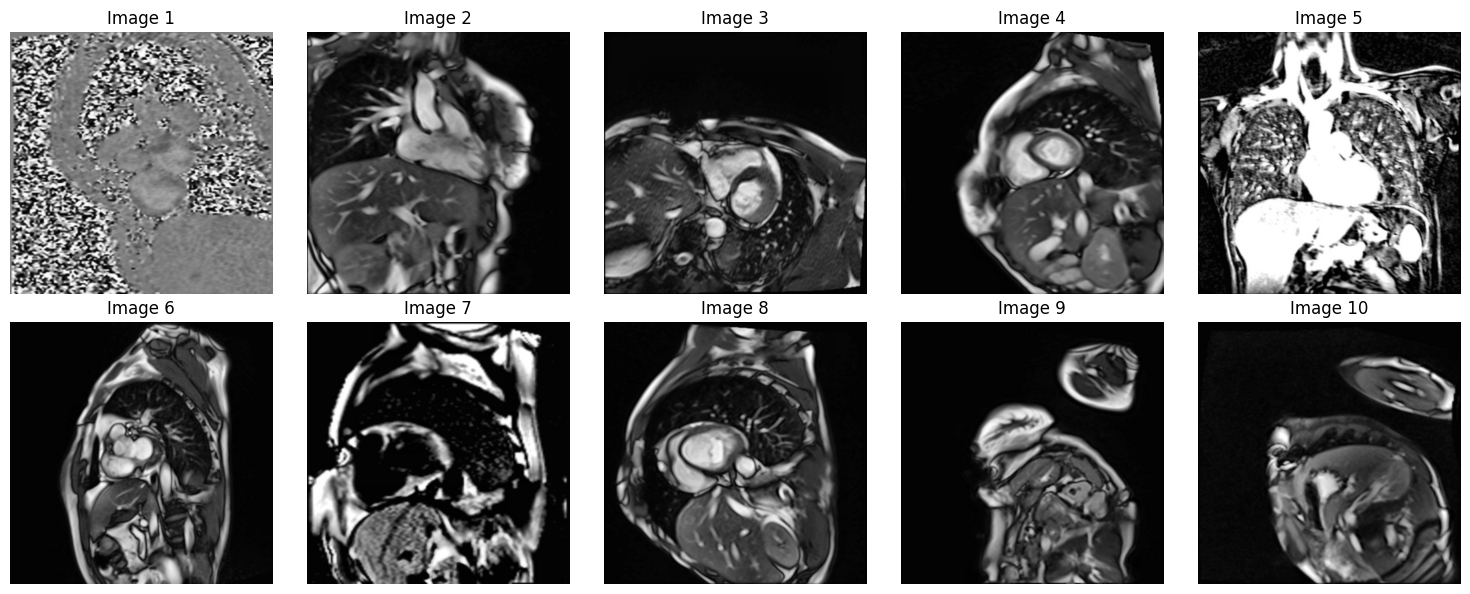

In [8]:
import random

normal_path = os.path.join(OUTPUT_DIR, "Normal")
sick_path = os.path.join(OUTPUT_DIR, "Sick")

num_images = 10  
cols = 5 
rows = (num_images + cols - 1) // cols  
normal_images = random.sample(os.listdir(normal_path), num_images // 2)
sick_images = random.sample(os.listdir(sick_path), num_images // 2)

image_files = [os.path.join(normal_path, img) for img in normal_images] + \
              [os.path.join(sick_path, img) for img in sick_images]

plt.figure(figsize=(15, rows * 3))

for i in range(len(image_files)):
    img = cv2.imread(image_files[i])

    plt.subplot(rows, cols, i + 1)
    plt.imshow(img)
    plt.axis('off')
    plt.title(f"Image {i+1}")

plt.tight_layout()
plt.show()

Sick Data Augmentation for balancing

In [9]:
sick_folder = "/kaggle/working/new_dataset/Sick"

sick_images = glob.glob(os.path.join(sick_folder, "*.*"))
random.shuffle(sick_images)  

augmentations = A.Compose([
    A.HorizontalFlip(),
    A.Rotate(limit=15, p=0.5),
    A.RandomBrightnessContrast(p=1),
    A.GaussianBlur(p=0.3),
    A.RandomResizedCrop(height=512, width=512, scale=(0.8, 1.0), p=0.5)
])

def augment_and_save(image_path, save_dir):
    """Applies augmentation to an image and saves it."""
    img = cv2.imread(image_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    augmented = augmentations(image=img)['image']
    augmented = cv2.cvtColor(augmented, cv2.COLOR_RGB2BGR)
    filename = f"aug_{random.randint(10000, 99999)}_{os.path.basename(image_path)}"
    cv2.imwrite(os.path.join(save_dir, filename), augmented)

# Keep augmenting until Sick folder reaches 37,500 images
print("Augmenting Sick images...")
while len(glob.glob(os.path.join(sick_folder, "*.*"))) < 37500:
    for img_path in tqdm(sick_images, total=len(sick_images)):
        if len(glob.glob(os.path.join(sick_folder, "*.*"))) >= 37500:
            break
        augment_and_save(img_path, sick_folder)

print(f"🎯 Augmentation completed! Total images in Sick: {len(glob.glob(os.path.join(sick_folder, '*.*')))}")


Augmenting Sick images...


 45%|████▌     | 11639/25861 [17:40<21:36, 10.97it/s]


🎯 Augmentation completed! Total images in Sick: 37500


In [10]:
normal_dir = os.path.join(OUTPUT_DIR, "Normal")
sick_dir = os.path.join(OUTPUT_DIR, "Sick")

num_normal = len(os.listdir(normal_dir)) if os.path.exists(normal_dir) else 0
num_sick = len(os.listdir(sick_dir)) if os.path.exists(sick_dir) else 0

print(f"Normal images: {num_normal}")
print(f"Sick images: {num_sick}")
print(f"Total images: {num_normal + num_sick}")


Normal images: 37564
Sick images: 37500
Total images: 75064


Splitting Our dataset

In [11]:
output_path = "/kaggle/working/splitted_dataset"
for split in ["train", "valid", "test"]:
    for category in ["Normal", "Sick"]:
        os.makedirs(os.path.join(output_path, split, category), exist_ok=True)

In [12]:
import os
import shutil
from sklearn.model_selection import train_test_split

# Define input (original dataset) and output (splitted dataset) directories
SOURCE_DIR = "/kaggle/working/new_dataset"  # Change to your actual dataset path
OUTPUT_DIR = "/kaggle/working/splitted_dataset"  # Change to where you want to store the split dataset

# Ensure the output directory exists
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Define subdirectories inside OUTPUT_DIR for train, val, and test
for split in ["train", "val", "test"]:
    os.makedirs(os.path.join(OUTPUT_DIR, split, "Normal"), exist_ok=True)
    os.makedirs(os.path.join(OUTPUT_DIR, split, "Sick"), exist_ok=True)

# Function to split and copy images
def split_and_copy(class_name):
    class_dir = os.path.join(SOURCE_DIR, class_name)  # Path to original class folder
    images = os.listdir(class_dir)

    # Split dataset (70% Train, 15% Validation, 15% Test)
    train_files, test_val_files = train_test_split(images, test_size=0.3, random_state=42)
    val_files, test_files = train_test_split(test_val_files, test_size=0.5, random_state=42)

    # Define destination directories
    train_dest = os.path.join(OUTPUT_DIR, "train", class_name)
    val_dest = os.path.join(OUTPUT_DIR, "val", class_name)
    test_dest = os.path.join(OUTPUT_DIR, "test", class_name)

    # Copy files to respective directories
    for file in train_files:
        shutil.copy2(os.path.join(class_dir, file), os.path.join(train_dest, file))
    for file in val_files:
        shutil.copy2(os.path.join(class_dir, file), os.path.join(val_dest, file))
    for file in test_files:
        shutil.copy2(os.path.join(class_dir, file), os.path.join(test_dest, file))

    return len(train_files), len(val_files), len(test_files)

# Split and copy images for each class
train_n, val_n, test_n = split_and_copy("Normal")
train_s, val_s, test_s = split_and_copy("Sick")

# Print dataset distribution
print(f"Train: {train_n + train_s} images stored in {os.path.join(OUTPUT_DIR, 'train')}")
print(f"Validation: {val_n + val_s} images stored in {os.path.join(OUTPUT_DIR, 'val')}")
print(f"Test: {test_n + test_s} images stored in {os.path.join(OUTPUT_DIR, 'test')}")

Train: 52544 images stored in /kaggle/working/splitted_dataset/train
Validation: 11260 images stored in /kaggle/working/splitted_dataset/val
Test: 11260 images stored in /kaggle/working/splitted_dataset/test


In [13]:
splitted_dataset = "/kaggle/working/splitted_dataset" 

def count_images(folder):
    return len([f for f in os.listdir(folder) if f.endswith(('.png', '.jpg', '.jpeg'))])

# Define paths
train_normal = os.path.join(splitted_dataset, "train", "Normal")
valid_normal = os.path.join(splitted_dataset, "val", "Normal")
test_normal = os.path.join(splitted_dataset, "test", "Normal")

train_sick = os.path.join(splitted_dataset, "train", "Sick")
valid_sick = os.path.join(splitted_dataset, "val", "Sick")
test_sick = os.path.join(splitted_dataset, "test", "Sick")

# Print counts
print("Training set - Normal:", count_images(train_normal))
print("Validation set - Normal:", count_images(valid_normal))
print("Test set - Normal:", count_images(test_normal))

print("Training set - Sick:", count_images(train_sick))
print("Validation set - Sick:", count_images(valid_sick))
print("Test set - Sick:", count_images(test_sick))


Training set - Normal: 26294
Validation set - Normal: 5635
Test set - Normal: 5635
Training set - Sick: 26250
Validation set - Sick: 5625
Test set - Sick: 5625


In [20]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model

# Paths
train_dir = "/kaggle/working/splitted_dataset/train"
val_dir   = "/kaggle/working/splitted_dataset/val"
test_dir  = "/kaggle/working/splitted_dataset/test"

# Image parameters
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

# Data augmentation (helps generalization)
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.2,
    horizontal_flip=True
)

val_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

# Load datasets
train_data = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary"
)

val_data = val_datagen.flow_from_directory(
    val_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary"
)

test_data = test_datagen.flow_from_directory(
    test_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary"
)

# Load MobileNetV2 base model (without top layers)
base_model = MobileNetV2(weights="imagenet", include_top=False, input_shape=(224,224,3))
base_model.trainable = False  # Freeze layers for faster training

# Add custom layers
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.3)(x)
x = Dense(128, activation="relu")(x)
output = Dense(1, activation="sigmoid")(x)  # Binary classification

model = Model(inputs=base_model.input, outputs=output)

# Compile model
model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])

# Train model
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=5,   # very few epochs
    verbose=1
)

# Evaluate on test data
loss, acc = model.evaluate(test_data)
print(f"Test Accuracy: {acc*100:.2f}%")


Found 52544 images belonging to 2 classes.
Found 11260 images belonging to 2 classes.
Found 11260 images belonging to 2 classes.
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/5


/usr/local/lib/python3.10/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:122: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


1642/1642 ━━━━━━━━━━━━━━━━━━━━ 610s 364ms/step - accuracy: 0.7445 - loss: 0.5138 - val_accuracy: 0.8602 - val_loss: 0.3169
Epoch 2/5
1642/1642 ━━━━━━━━━━━━━━━━━━━━ 595s 361ms/step - accuracy: 0.8500 - loss: 0.3344 - val_accuracy: 0.9037 - val_loss: 0.2240
Epoch 3/5
1642/1642 ━━━━━━━━━━━━━━━━━━━━ 595s 361ms/step - accuracy: 0.8767 - loss: 0.2836 - val_accuracy: 0.9141 - val_loss: 0.2001
Epoch 4/5
1642/1642 ━━━━━━━━━━━━━━━━━━━━ 594s 360ms/step - accuracy: 0.8924 - loss: 0.2482 - val_accuracy: 0.9142 - val_loss: 0.1947
Epoch 5/5
1642/1642 ━━━━━━━━━━━━━━━━━━━━ 591s 359ms/step - accuracy: 0.9010 - loss: 0.2361 - val_accuracy: 0.9233 - val_loss: 0.1755
352/352 ━━━━━━━━━━━━━━━━━━━━ 27s 75ms/step - accuracy: 0.9303 - loss: 0.1661
Test Accuracy: 93.00%


In [23]:
model.save("/kaggle/working/CNN_model.h5")

In [25]:
model.save("/kaggle/working/CNN_model.h5")